ROOT file: /root/geant4/detector/Lung_ICRP/lung.root
File exists: True
Total TTree entries: 1000000

Selection summary
-----------------
Entries satisfying pdg/pro/vlm: 26967
Valid reconstructed events: 26967
Rejected because of E': 0
Rejected because of direction: 0
Rejected because q <= 0: 0

First 10 rows:
   Q_signed_au  Q_absolute_au  Eprime_keV  E0_keV  E0_minus_Eprime_keV  \
0   -27.857101      27.857101  268.227291   662.0           393.772709   
1    -1.684865       1.684865  606.605257   662.0            55.394743   
2   -15.411591      15.411591  494.409310   662.0           167.590690   
3    -1.443702       1.443702  612.111201   662.0            49.888799   
4   -35.251490      35.251490  193.327690   662.0           468.672310   
5    -3.307807       3.307807  574.287887   662.0            87.712113   
6    -8.647417       8.647417  491.508840   662.0           170.491160   
7   -27.972376      27.972376  267.030502   662.0           394.969498   
8   -34.618879      34.

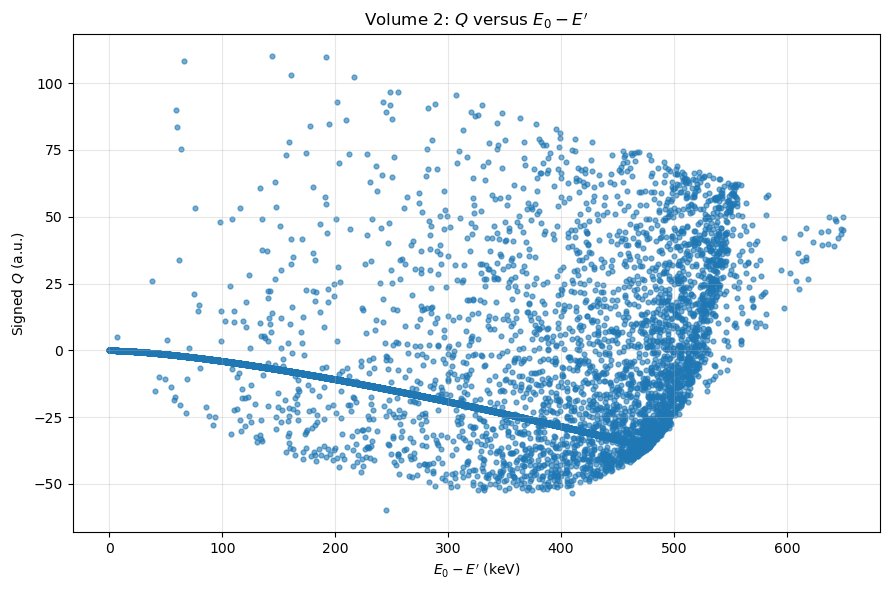

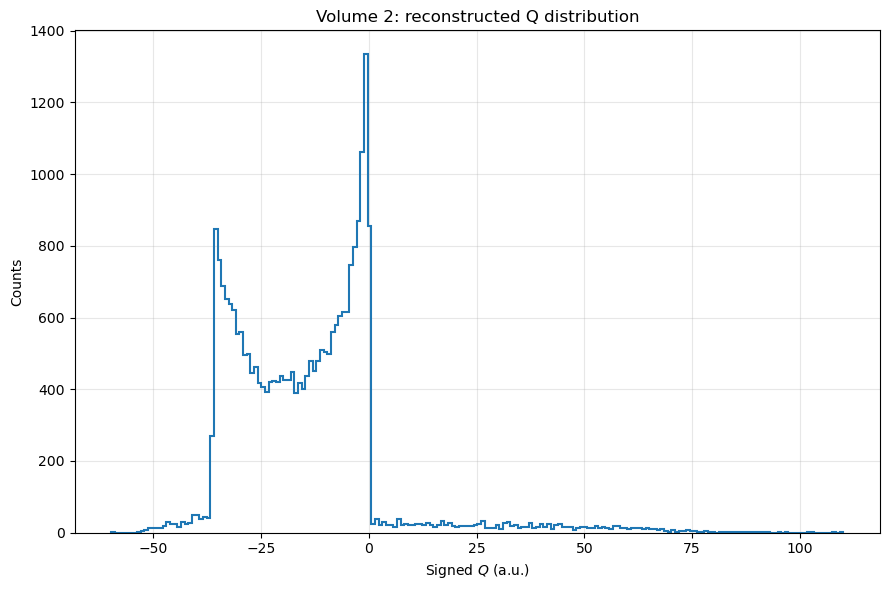


Saved CSV:
volume2_Q_vs_E0_minus_Eprime.csv


In [7]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================
file_path = "/root/geant4/detector/Lung_ICRP/lung.root"
tree_name = "t"

E0 = 662.0       # incident gamma energy, keV
ME = 511.0       # electron rest energy, keV
P_AU = 3.72738   # 1 a.u. momentum = 3.72738 keV/c

selected_volume = 2
compton_process = 2013
gamma_pdg = 22

# Incident beam direction: along -y
incident_direction = np.array([0.0, -1.0, 0.0])

# Output CSV
csv_file = "volume2_Q_vs_E0_minus_Eprime.csv"

# =====================================================
# CHECK FILE
# =====================================================
print("ROOT file:", file_path)
print("File exists:", os.path.exists(file_path))

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file does not exist:\n{file_path}"
    )

# =====================================================
# OPEN ROOT FILE
# =====================================================
root = ROOT.TFile.Open(file_path)

if not root or root.IsZombie():
    raise RuntimeError(
        f"Could not open ROOT file:\n{file_path}"
    )

tree = root.Get(tree_name)

if tree is None:
    root.Close()
    raise RuntimeError(
        f"TTree '{tree_name}' was not found."
    )

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# CHECK REQUIRED BRANCHES
# =====================================================
required_branches = [
    "pdg", "pro", "vlm",
    "k", "px", "py", "pz"
]

available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

missing_branches = [
    branch for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root.Close()
    raise RuntimeError(
        "Missing branches: "
        + ", ".join(missing_branches)
    )

# =====================================================
# STORAGE
# =====================================================
Q_values = []
Q_absolute_values = []

Eprime_values = []
energy_loss_values = []

theta_values = []
q_values = []

selected_entries = 0
rejected_energy = 0
rejected_direction = 0
rejected_q = 0

# =====================================================
# LOOP OVER TREE
# =====================================================
# =====================================================
# LOOP OVER TTREE EVENTS
# =====================================================
for entry in tree:

    # Number of stored steps/hits in this event
    n_steps = len(entry.pdg)

    for i in range(n_steps):

        pdg = int(entry.pdg[i])
        pro = int(entry.pro[i])
        vlm = int(entry.vlm[i])

        # Select gamma Compton interactions in volume 2
        if pdg != gamma_pdg:
            continue

        if pro != compton_process:
            continue

        if vlm != selected_volume:
            continue

        selected_entries += 1

        # -------------------------------------------------
        # Outgoing scattered gamma energy E' = k
        # -------------------------------------------------
        Eprime = float(entry.k[i])

        if not np.isfinite(Eprime):
            rejected_energy += 1
            continue

        if Eprime <= 0.0 or Eprime > E0:
            rejected_energy += 1
            continue

        # -------------------------------------------------
        # Outgoing gamma direction
        # -------------------------------------------------
        outgoing_vector = np.array([
            float(entry.px[i]),
            float(entry.py[i]),
            float(entry.pz[i])
        ])

        outgoing_magnitude = np.linalg.norm(outgoing_vector)

        if (
            not np.isfinite(outgoing_magnitude)
            or outgoing_magnitude == 0.0
        ):
            rejected_direction += 1
            continue

        outgoing_direction = (
            outgoing_vector / outgoing_magnitude
        )

        # -------------------------------------------------
        # Scattering angle
        # -------------------------------------------------
        cos_theta = np.dot(
            incident_direction,
            outgoing_direction
        )

        cos_theta = np.clip(cos_theta, -1.0, 1.0)

        theta_rad = np.arccos(cos_theta)
        theta_deg = np.degrees(theta_rad)

        # -------------------------------------------------
        # Energy loss E0 - E'
        # -------------------------------------------------
        energy_loss = E0 - Eprime

        # -------------------------------------------------
        # Photon momentum transfer q_gamma*c
        # -------------------------------------------------
        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * cos_theta
        )

        q_squared = max(q_squared, 0.0)
        q_c = np.sqrt(q_squared)

        if not np.isfinite(q_c) or q_c <= 0.0:
            rejected_q += 1
            continue

        # -------------------------------------------------
        # Longitudinal electron momentum Q
        # -------------------------------------------------
        Q_keV_c = (
            ME / q_c
        ) * (
            energy_loss
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            continue

        # -------------------------------------------------
        # Save valid interaction
        # -------------------------------------------------
        Q_values.append(Q_au)
        Q_absolute_values.append(abs(Q_au))

        Eprime_values.append(Eprime)
        energy_loss_values.append(energy_loss)

        theta_values.append(theta_deg)
        q_values.append(q_c)
# =====================================================
# CONVERT TO NUMPY ARRAYS
# =====================================================
Q_values = np.asarray(Q_values)
Q_absolute_values = np.asarray(
    Q_absolute_values
)

Eprime_values = np.asarray(Eprime_values)
energy_loss_values = np.asarray(
    energy_loss_values
)

theta_values = np.asarray(theta_values)
q_values = np.asarray(q_values)

# =====================================================
# SUMMARY
# =====================================================
print("\nSelection summary")
print("-----------------")
print(
    "Entries satisfying pdg/pro/vlm:",
    selected_entries
)
print(
    "Valid reconstructed events:",
    len(Q_values)
)
print(
    "Rejected because of E':",
    rejected_energy
)
print(
    "Rejected because of direction:",
    rejected_direction
)
print(
    "Rejected because q <= 0:",
    rejected_q
)

if len(Q_values) == 0:
    root.Close()
    raise RuntimeError(
        "No valid events were reconstructed.\n"
        "Check whether:\n"
        "1. vlm == 2 is correct,\n"
        "2. pro == 2013 is correct,\n"
        "3. k is the outgoing gamma energy,\n"
        "4. px, py, pz describe the outgoing gamma."
    )

# =====================================================
# SAVE EVENT-BY-EVENT CSV
# =====================================================
output_table = pd.DataFrame({
    "Q_signed_au": Q_values,
    "Q_absolute_au": Q_absolute_values,
    "Eprime_keV": Eprime_values,
    "E0_keV": np.full(
        len(Q_values),
        E0
    ),
    "E0_minus_Eprime_keV":
        energy_loss_values,
    "Eprime_minus_E0_keV":
        Eprime_values - E0,
    "theta_deg": theta_values,
    "q_gamma_keV_c": q_values
})

output_table.to_csv(
    csv_file,
    index=False
)

print("\nFirst 10 rows:")
print(output_table.head(10))

# =====================================================
# PLOT 1: Q VERSUS E0-E'
# =====================================================
plt.figure(figsize=(9, 6))

plt.scatter(
    energy_loss_values,
    Q_values,
    s=12,
    alpha=0.6
)

plt.xlabel(r"$E_0-E'$ (keV)")
plt.ylabel(r"Signed $Q$ (a.u.)")
plt.title(
    r"Volume 2: $Q$ versus $E_0-E'$"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# =====================================================
# PLOT 4: Q DISTRIBUTION
# =====================================================
plt.figure(figsize=(9, 6))

plt.hist(
    Q_values,
    bins=200,
    histtype="step",
    linewidth=1.5
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel("Counts")
plt.title(
    "Volume 2: reconstructed Q distribution"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# CLOSE ROOT FILE
# =====================================================
root.Close()

print("\nSaved CSV:")
print(csv_file)

ROOT file: /root/geant4/detector/Lung_ICRP/lung.root
File exists: True
Total TTree entries: 1000000

Selection summary
-----------------

Volume 2
Selected records: 26967
Valid Q records: 26967
Rejected energy: 0
Rejected direction: 0
Rejected q/Q: 0

Volume 3
Selected records: 89989
Valid Q records: 89989
Rejected energy: 0
Rejected direction: 0
Rejected q/Q: 0

First 10 event rows:
   event_number  record_index  volume  pdg   pro  E0_keV  Eprime_keV  \
0            11             3       3   22  2013   662.0  502.979975   
1            17             3       3   22  2013   662.0  514.247410   
2            19             3       3   22  2013   662.0  505.559703   
3            22             3       3   22  2013   662.0  184.489350   
4            61             3       3   22  2013   662.0  277.305046   
5            62             3       3   22  2013   662.0  189.040815   
6            68             2       2   22  2013   662.0  268.227291   
7            69             4       2

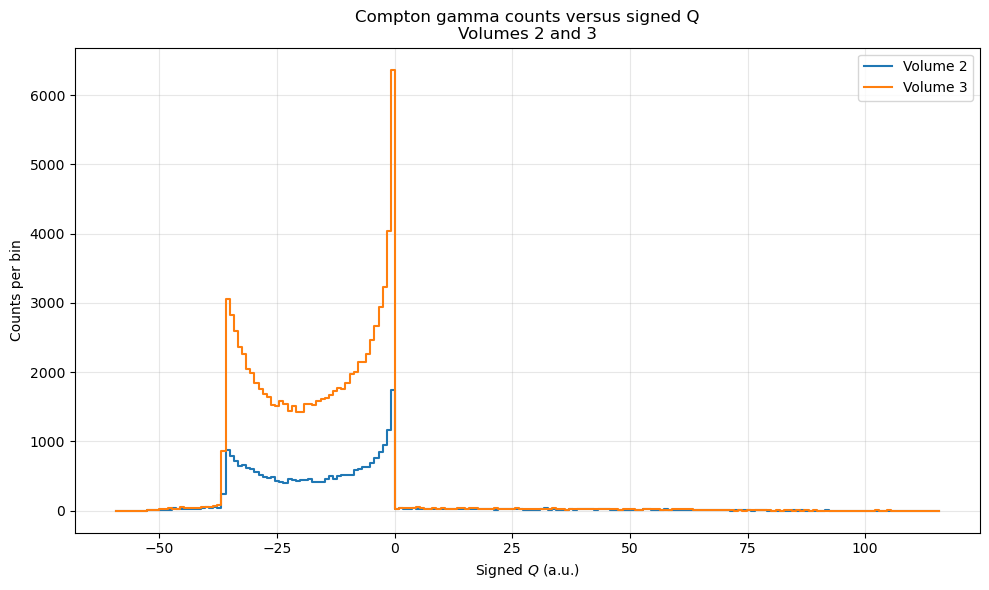

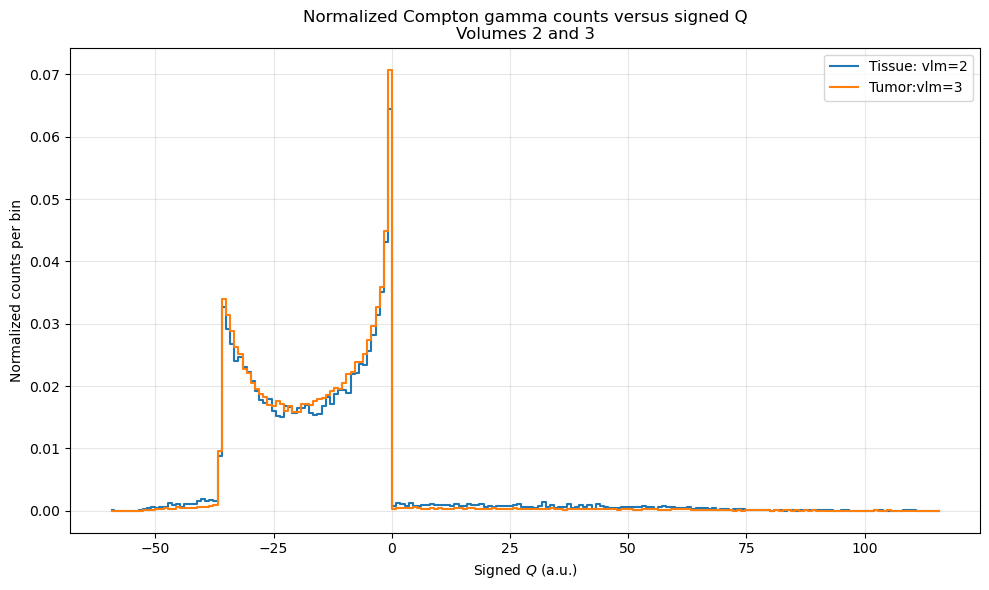


Saved event CSV:
volume2_volume3_Q_events.csv

Saved counts-versus-Q CSV:
volume2_volume3_counts_vs_Q.csv


In [9]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================
file_path = "/root/geant4/detector/Lung_ICRP/lung.root"
tree_name = "t"

E0 = 662.0       # Incident gamma energy, keV
ME = 511.0       # Electron rest energy, keV
P_AU = 3.72738   # 1 a.u. momentum = 3.72738 keV/c

selected_volumes = [2, 3]
compton_process = 2013
gamma_pdg = 22

# Incident beam direction: /gps/direction 0 -1 0
incident_direction = np.array(
    [0.0, -1.0, 0.0],
    dtype=float
)
incident_direction /= np.linalg.norm(incident_direction)

# Histogram settings
number_of_Q_bins = 200

# Output files
events_csv_file = "volume2_volume3_Q_events.csv"
counts_csv_file = "volume2_volume3_counts_vs_Q.csv"

volume_names = {
    2: "Volume 2",
    3: "Volume 3"
}

# =====================================================
# CHECK AND OPEN ROOT FILE
# =====================================================
print("ROOT file:", file_path)
print("File exists:", os.path.exists(file_path))

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file does not exist:\n{file_path}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError(
        f"Could not open ROOT file:\n{file_path}"
    )

tree = root_file.Get(tree_name)

if tree is None:
    root_file.Close()
    raise RuntimeError(
        f"TTree '{tree_name}' was not found."
    )

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# CHECK REQUIRED ALIGNED BRANCHES
# =====================================================
required_branches = [
    "pdg", "pro", "vlm",
    "k", "px", "py", "pz"
]

available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

missing_branches = [
    branch
    for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root_file.Close()
    raise RuntimeError(
        "Missing branches: " + ", ".join(missing_branches)
    )

# =====================================================
# STORAGE
# =====================================================
rows = []

summary_counters = {
    volume: {
        "selected": 0,
        "valid": 0,
        "rejected_energy": 0,
        "rejected_direction": 0,
        "rejected_q": 0
    }
    for volume in selected_volumes
}

# =====================================================
# LOOP OVER TTREE EVENTS
# =====================================================
for event_number, entry in enumerate(tree):

    # Use only aligned tracking branches.
    n_steps = min(
        len(entry.pdg),
        len(entry.pro),
        len(entry.vlm),
        len(entry.k),
        len(entry.px),
        len(entry.py),
        len(entry.pz)
    )

    for i in range(n_steps):

        pdg = int(entry.pdg[i])
        process = int(entry.pro[i])
        volume = int(entry.vlm[i])

        # Gamma Compton records in volume 2 or 3
        if volume not in selected_volumes:
            continue

        if pdg != gamma_pdg:
            continue

        if process != compton_process:
            continue

        summary_counters[volume]["selected"] += 1

        # -------------------------------------------------
        # Scattered gamma energy E' = k
        # -------------------------------------------------
        Eprime = float(entry.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            summary_counters[volume]["rejected_energy"] += 1
            continue

        # -------------------------------------------------
        # Outgoing photon direction
        # -------------------------------------------------
        px = float(entry.px[i])
        py = float(entry.py[i])
        pz = float(entry.pz[i])

        outgoing_vector = np.array(
            [px, py, pz],
            dtype=float
        )

        outgoing_magnitude = np.linalg.norm(outgoing_vector)

        if (
            not np.isfinite(outgoing_magnitude)
            or outgoing_magnitude <= 0.0
        ):
            summary_counters[volume]["rejected_direction"] += 1
            continue

        outgoing_direction = (
            outgoing_vector / outgoing_magnitude
        )

        # -------------------------------------------------
        # Scattering angle
        # -------------------------------------------------
        cos_theta = float(
            np.dot(
                incident_direction,
                outgoing_direction
            )
        )

        cos_theta = float(
            np.clip(cos_theta, -1.0, 1.0)
        )

        theta_rad = np.arccos(cos_theta)
        theta_deg = np.degrees(theta_rad)

        # -------------------------------------------------
        # Energy loss
        # -------------------------------------------------
        energy_loss = E0 - Eprime

        # -------------------------------------------------
        # Photon momentum transfer q*c
        # -------------------------------------------------
        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * cos_theta
        )

        if not np.isfinite(q_squared) or q_squared <= 0.0:
            summary_counters[volume]["rejected_q"] += 1
            continue

        q_c = np.sqrt(q_squared)

        # -------------------------------------------------
        # Longitudinal electron momentum Q
        # -------------------------------------------------
        Q_keV_c = (
            ME / q_c
        ) * (
            energy_loss
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            summary_counters[volume]["rejected_q"] += 1
            continue

        rows.append({
            "event_number": event_number,
            "record_index": i,
            "volume": volume,
            "pdg": pdg,
            "pro": process,
            "E0_keV": E0,
            "Eprime_keV": Eprime,
            "E0_minus_Eprime_keV": energy_loss,
            "px": px,
            "py": py,
            "pz": pz,
            "cos_theta": cos_theta,
            "theta_deg": theta_deg,
            "q_gamma_keV_c": q_c,
            "Q_keV_c": Q_keV_c,
            "Q_signed_au": Q_au,
            "Q_absolute_au": abs(Q_au)
        })

        summary_counters[volume]["valid"] += 1

root_file.Close()

# =====================================================
# CREATE EVENT DATAFRAME
# =====================================================
events_df = pd.DataFrame(rows)

if events_df.empty:
    raise RuntimeError(
        "No valid Compton gamma records were reconstructed "
        "for volumes 2 and 3."
    )

# Save all event-by-event values in one CSV
events_df.to_csv(
    events_csv_file,
    index=False
)

# Separate arrays for plotting
Q_volume2 = events_df.loc[
    events_df["volume"] == 2,
    "Q_signed_au"
].to_numpy()

Q_volume3 = events_df.loc[
    events_df["volume"] == 3,
    "Q_signed_au"
].to_numpy()

print("\nSelection summary")
print("-----------------")

for volume in selected_volumes:
    counters = summary_counters[volume]

    print(f"\nVolume {volume}")
    print("Selected records:", counters["selected"])
    print("Valid Q records:", counters["valid"])
    print("Rejected energy:", counters["rejected_energy"])
    print("Rejected direction:", counters["rejected_direction"])
    print("Rejected q/Q:", counters["rejected_q"])

# =====================================================
# COMMON Q BIN EDGES
# =====================================================
# Use the same bins for both volumes so the counts
# can be compared directly.
Q_all = events_df["Q_signed_au"].to_numpy()

Q_min = np.nanmin(Q_all)
Q_max = np.nanmax(Q_all)

Q_bin_edges = np.linspace(
    Q_min,
    Q_max,
    number_of_Q_bins + 1
)

counts_volume2, _ = np.histogram(
    Q_volume2,
    bins=Q_bin_edges
)

counts_volume3, _ = np.histogram(
    Q_volume3,
    bins=Q_bin_edges
)

Q_bin_left = Q_bin_edges[:-1]
Q_bin_right = Q_bin_edges[1:]

Q_bin_center = 0.5 * (
    Q_bin_left + Q_bin_right
)

# =====================================================
# SAVE COUNTS VS Q CSV
# =====================================================
counts_df = pd.DataFrame({
    "Q_bin_left_au": Q_bin_left,
    "Q_bin_right_au": Q_bin_right,
    "Q_bin_center_au": Q_bin_center,
    "Volume2_counts": counts_volume2,
    "Volume3_counts": counts_volume3
})

counts_df.to_csv(
    counts_csv_file,
    index=False
)

print("\nFirst 10 event rows:")
print(events_df.head(10))

print("\nFirst 10 counts-vs-Q rows:")
print(counts_df.head(10))

# =====================================================
# PLOT COUNTS VS SIGNED Q
# =====================================================
plt.figure(figsize=(10, 6))

plt.step(
    Q_bin_center,
    counts_volume2,
    where="mid",
    linewidth=1.5,
    label="Tissue:Volume 2"
)

plt.step(
    Q_bin_center,
    counts_volume3,
    where="mid",
    linewidth=1.5,
    label="Tumor: Volume 3"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel("Counts per bin")
plt.title(
    "Compton gamma counts versus signed Q\n"
    " Tumor and Tissue"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# OPTIONAL: NORMALIZED COUNTS VS Q
# =====================================================
# This compares the shapes independently of the
# different total numbers of events.
normalized_counts_volume2 = (
    counts_volume2 / counts_volume2.sum()
    if counts_volume2.sum() > 0
    else counts_volume2.astype(float)
)

normalized_counts_volume3 = (
    counts_volume3 / counts_volume3.sum()
    if counts_volume3.sum() > 0
    else counts_volume3.astype(float)
)

plt.figure(figsize=(10, 6))

plt.step(
    Q_bin_center,
    normalized_counts_volume2,
    where="mid",
    linewidth=1.5,
    label="Tissue: vlm=2"
)

plt.step(
    Q_bin_center,
    normalized_counts_volume3,
    where="mid",
    linewidth=1.5,
    label="Tumor:vlm=3"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel("Normalized counts per bin")
plt.title(
    "Normalized Compton gamma counts versus signed Q\n"
    "Volumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSaved event CSV:")
print(events_csv_file)

print("\nSaved counts-versus-Q CSV:")
print(counts_csv_file)

Total TTree entries: 1000000

Valid records:
Volume 2: 26967
Volume 3: 89989

First 10 rows:
   event_number  record_index  volume  pdg   pro  E0_keV  Eprime_k_keV  \
0            11             3       3   22  2013   662.0    502.979975   
1            17             3       3   22  2013   662.0    514.247410   
2            19             3       3   22  2013   662.0    505.559703   
3            22             3       3   22  2013   662.0    184.489350   
4            61             3       3   22  2013   662.0    277.305046   
5            62             3       3   22  2013   662.0    189.040815   
6            68             2       2   22  2013   662.0    268.227291   
7            69             4       2   22  2013   662.0    606.605257   
8            69             5       2   22  2013   662.0    494.409310   
9            74             3       3   22  2013   662.0    311.501775   

   Et_E0_minus_Eprime_keV   theta_deg  q_gamma_keV_c     Q_keV_c  Q_signed_au  \
0          

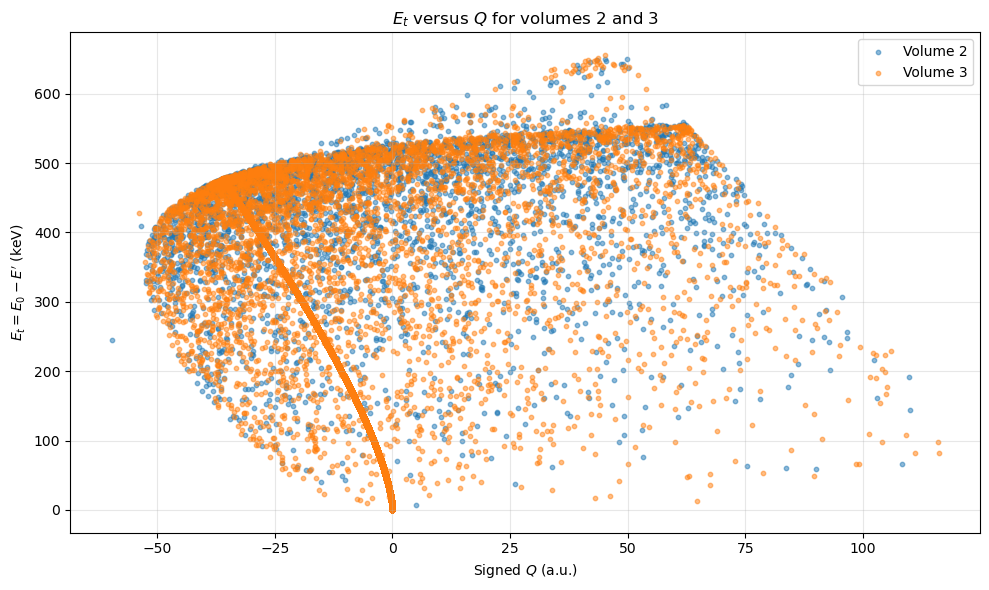

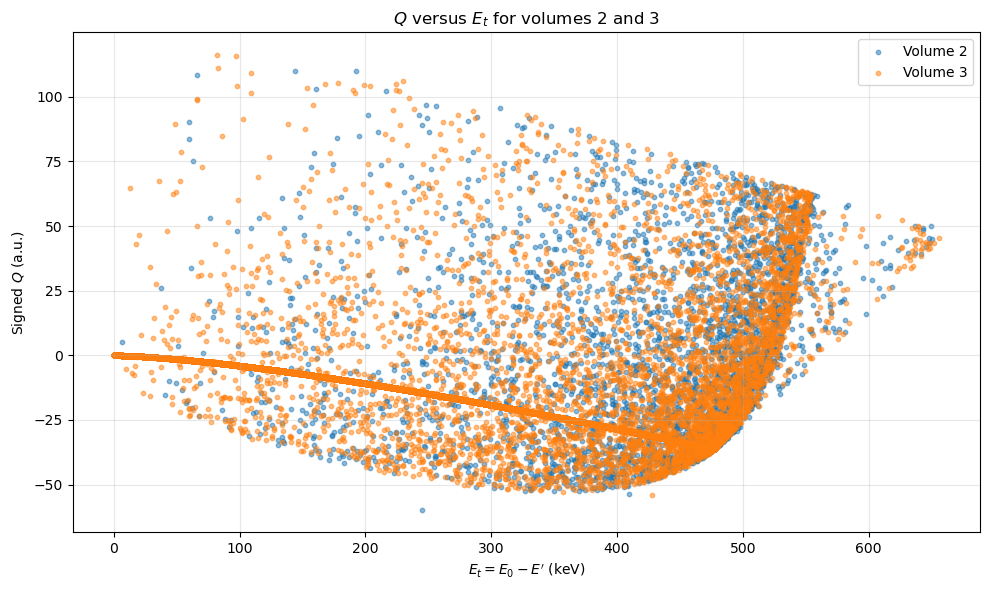


Saved CSV:
volume2_volume3_Et_vs_Q.csv


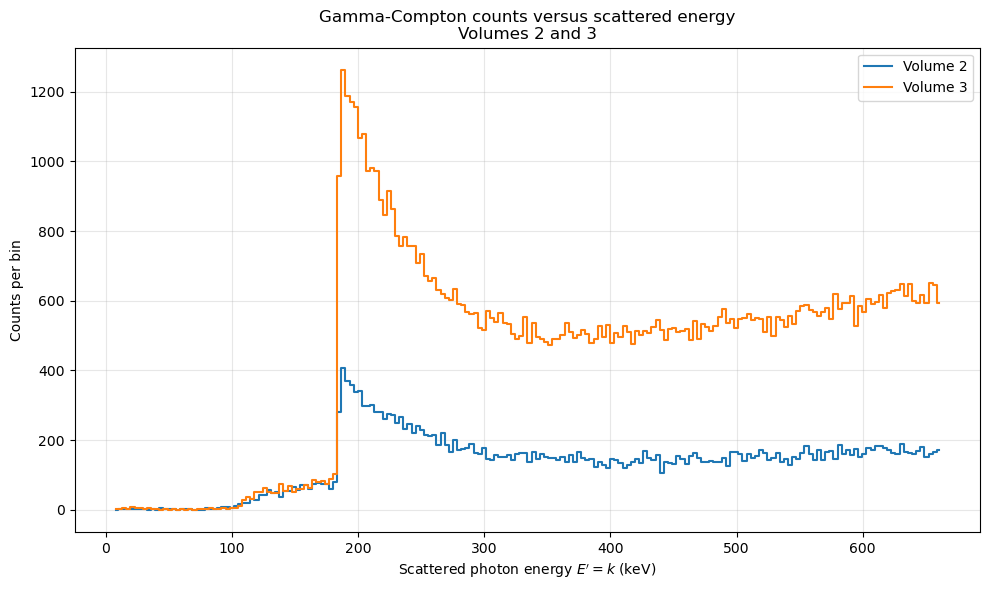


Saved event-by-event CSV:
volume2_volume3_energy_transfer_events.csv

Saved counts-versus-energy-transfer CSV:
volume2_volume3_counts_vs_energy_transfer.csv


In [18]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================
file_path = "/root/geant4/detector/Lung_ICRP/lung.root"
tree_name = "t"

E0 = 662.0
ME = 511.0
P_AU = 3.72738

selected_volumes = [2, 3]
compton_process = 2013
gamma_pdg = 22

incident_direction = np.array(
    [0.0, -1.0, 0.0],
    dtype=float
)
incident_direction /= np.linalg.norm(incident_direction)

csv_file = "volume2_volume3_Et_vs_Q.csv"

# =====================================================
# OPEN ROOT FILE
# =====================================================
if not os.path.exists(file_path):
    raise FileNotFoundError(file_path)

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError("Could not open ROOT file.")

tree = root_file.Get(tree_name)

if tree is None:
    root_file.Close()
    raise RuntimeError(f"TTree '{tree_name}' was not found.")

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# STORAGE
# =====================================================
rows = []

counts = {
    2: 0,
    3: 0
}

# =====================================================
# LOOP OVER TTREE
# =====================================================
for event_number, event in enumerate(tree):

    n_records = min(
        len(event.pdg),
        len(event.pro),
        len(event.vlm),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    for i in range(n_records):

        pdg = int(event.pdg[i])
        process = int(event.pro[i])
        volume = int(event.vlm[i])

        if volume not in selected_volumes:
            continue

        if pdg != gamma_pdg:
            continue

        if process != compton_process:
            continue

        # Scattered gamma energy
        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            continue

        # Energy transfer
        Et = E0 - Eprime

        # Outgoing momentum vector
        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        momentum = np.array(
            [px, py, pz],
            dtype=float
        )

        momentum_magnitude = np.linalg.norm(momentum)

        if (
            not np.isfinite(momentum_magnitude)
            or momentum_magnitude <= 0.0
        ):
            continue

        outgoing_direction = (
            momentum / momentum_magnitude
        )

        # Actual scattering angle
        cos_theta = float(
            np.dot(
                incident_direction,
                outgoing_direction
            )
        )

        cos_theta = float(
            np.clip(cos_theta, -1.0, 1.0)
        )

        theta_rad = np.arccos(cos_theta)
        theta_deg = np.degrees(theta_rad)

        # Photon momentum transfer
        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * cos_theta
        )

        if (
            not np.isfinite(q_squared)
            or q_squared <= 0.0
        ):
            continue

        q_c = np.sqrt(q_squared)

        # Longitudinal electron momentum
        Q_keV_c = (
            ME / q_c
        ) * (
            Et
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            continue

        rows.append({
            "event_number": event_number,
            "record_index": i,
            "volume": volume,
            "pdg": pdg,
            "pro": process,
            "E0_keV": E0,
            "Eprime_k_keV": Eprime,
            "Et_E0_minus_Eprime_keV": Et,
            "theta_deg": theta_deg,
            "q_gamma_keV_c": q_c,
            "Q_keV_c": Q_keV_c,
            "Q_signed_au": Q_au,
            "Q_absolute_au": abs(Q_au)
        })

        counts[volume] += 1

root_file.Close()

# =====================================================
# CREATE DATAFRAME
# =====================================================
results = pd.DataFrame(rows)

if results.empty:
    raise RuntimeError(
        "No valid records found for volumes 2 and 3."
    )

results.to_csv(csv_file, index=False)

print("\nValid records:")
print("Volume 2:", counts[2])
print("Volume 3:", counts[3])

print("\nFirst 10 rows:")
print(results.head(10))

# =====================================================
# SEPARATE VOLUMES
# =====================================================
v2 = results[results["volume"] == 2]
v3 = results[results["volume"] == 3]

# =====================================================
# PLOT 1: Et VERSUS Q
# =====================================================
plt.figure(figsize=(10, 6))

plt.scatter(
    v2["Q_signed_au"],
    v2["Et_E0_minus_Eprime_keV"],
    s=10,
    alpha=0.5,
    label="Volume 2"
)

plt.scatter(
    v3["Q_signed_au"],
    v3["Et_E0_minus_Eprime_keV"],
    s=10,
    alpha=0.5,
    label="Volume 3"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel(r"$E_t=E_0-E'$ (keV)")
plt.title(
    r"$E_t$ versus $Q$ for volumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2: Q VERSUS Et
# =====================================================
plt.figure(figsize=(10, 6))

plt.scatter(
    v2["Et_E0_minus_Eprime_keV"],
    v2["Q_signed_au"],
    s=10,
    alpha=0.5,
    label="Volume 2"
)

plt.scatter(
    v3["Et_E0_minus_Eprime_keV"],
    v3["Q_signed_au"],
    s=10,
    alpha=0.5,
    label="Volume 3"
)

plt.xlabel(r"$E_t=E_0-E'$ (keV)")
plt.ylabel(r"Signed $Q$ (a.u.)")
plt.title(
    r"$Q$ versus $E_t$ for volumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSaved CSV:")
print(csv_file)

# =====================================================
# OPTIONAL PLOT 3: COUNTS VS E'
# =====================================================
Eprime_all = events_df["Eprime_k_keV"].to_numpy()

Eprime_bin_edges = np.linspace(
    np.nanmin(Eprime_all),
    np.nanmax(Eprime_all),
    number_of_energy_bins + 1
)

Eprime_counts_v2, _ = np.histogram(
    Eprime_v2,
    bins=Eprime_bin_edges
)

Eprime_counts_v3, _ = np.histogram(
    Eprime_v3,
    bins=Eprime_bin_edges
)

Eprime_bin_center = 0.5 * (
    Eprime_bin_edges[:-1]
    + Eprime_bin_edges[1:]
)

plt.figure(figsize=(10, 6))

plt.step(
    Eprime_bin_center,
    Eprime_counts_v2,
    where="mid",
    linewidth=1.5,
    label="Volume 2"
)

plt.step(
    Eprime_bin_center,
    Eprime_counts_v3,
    where="mid",
    linewidth=1.5,
    label="Volume 3"
)

plt.xlabel(r"Scattered photon energy $E'=k$ (keV)")
plt.ylabel("Counts per bin")
plt.title(
    "Gamma-Compton counts versus scattered energy\n"
    "Volumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSaved event-by-event CSV:")
print(events_csv_file)

print("\nSaved counts-versus-energy-transfer CSV:")
print(counts_csv_file)

ROOT file: /root/geant4/detector/Lung_ICRP/lung.root
File exists: True
Total TTree entries: 1000000

Selection summary
-----------------

Volume 2
Selected records: 26967
Valid records: 26967
Rejected energy records: 0
Rejected q/Q records: 0

Volume 3
Selected records: 89989
Valid records: 89989
Rejected energy records: 0
Rejected q/Q records: 0

First 10 rows:
   event_number  record_index  volume  pdg   pro  E0_keV  Eprime_k_keV  \
0            11             3       3   22  2013   662.0    502.979975   
1            17             3       3   22  2013   662.0    514.247410   
2            19             3       3   22  2013   662.0    505.559703   
3            22             3       3   22  2013   662.0    184.489350   
4            61             3       3   22  2013   662.0    277.305046   
5            62             3       3   22  2013   662.0    189.040815   
6            68             2       2   22  2013   662.0    268.227291   
7            69             4       2   22 

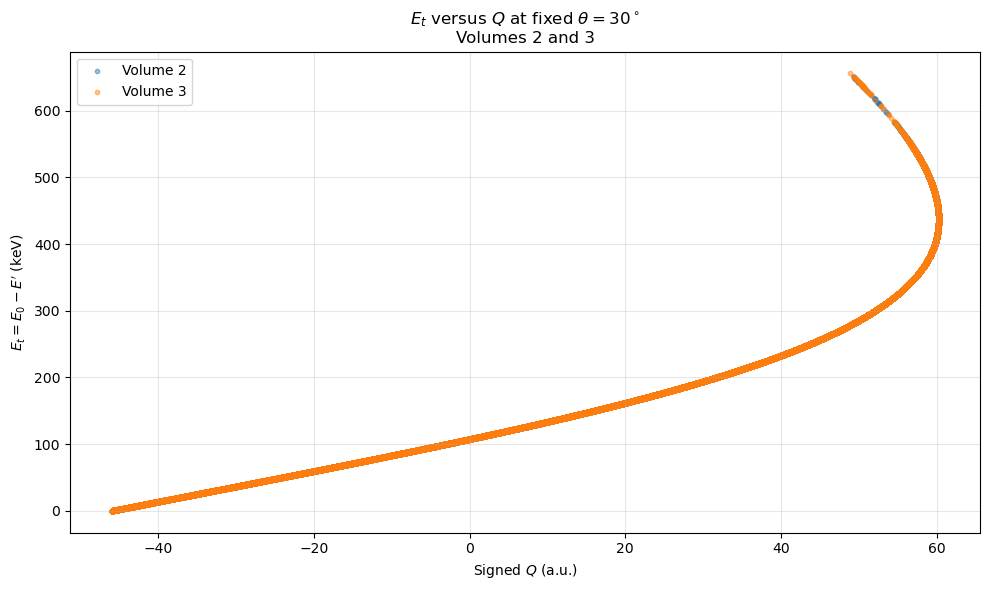

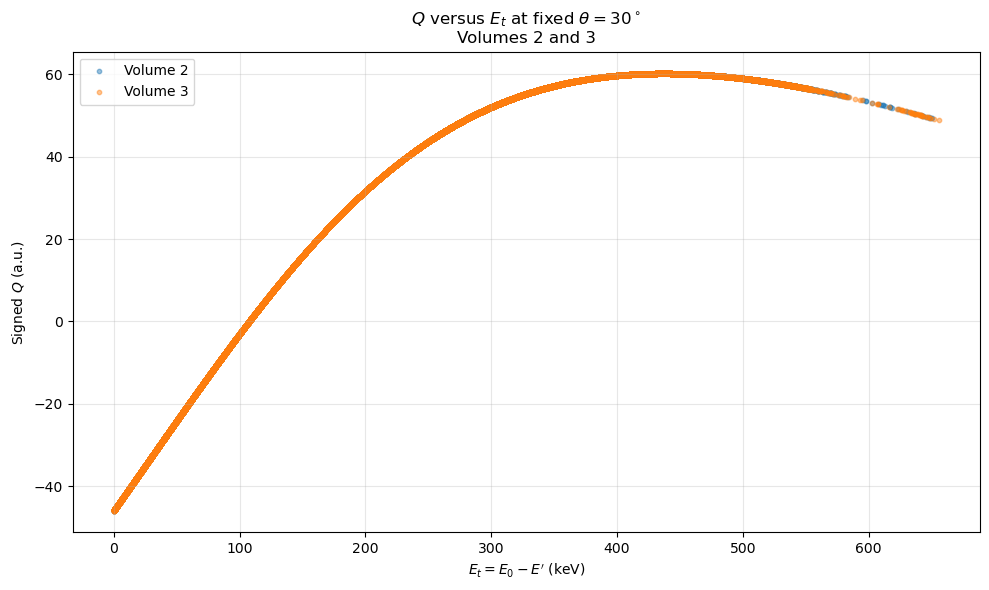

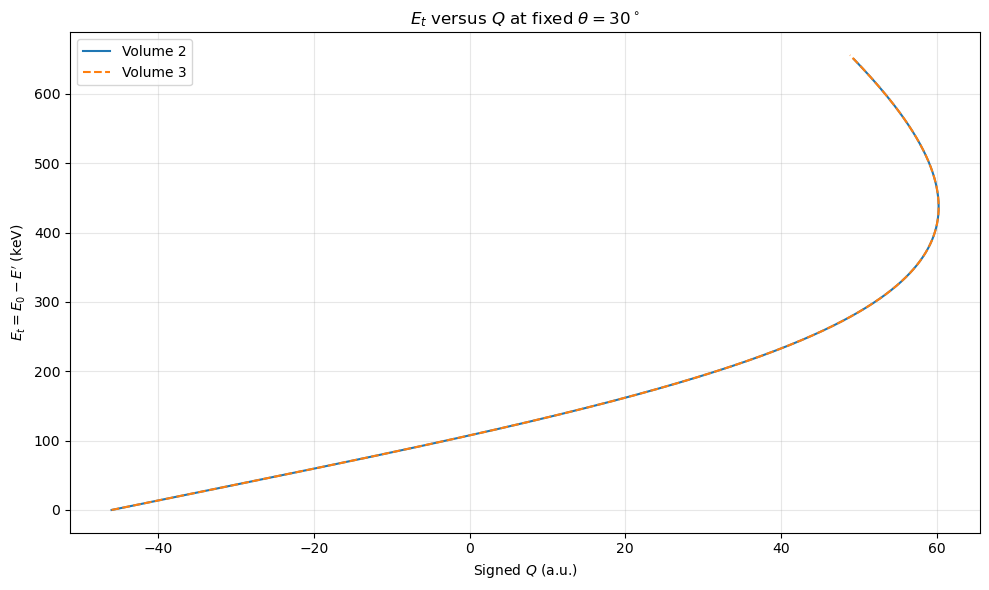


Saved CSV:
volume2_volume3_Et_vs_Q_fixed_theta30.csv


In [12]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================
file_path = "/root/geant4/detector/Lung_ICRP/lung.root"
tree_name = "t"

E0 = 662.0       # Incident gamma energy, keV
ME = 511.0       # Electron rest energy, keV
P_AU = 3.72738   # 1 a.u. momentum = 3.72738 keV/c

selected_volumes = [2, 3]
compton_process = 2013
gamma_pdg = 22

# Fixed scattering angle
fixed_theta_deg = 30.0
fixed_theta_rad = np.radians(fixed_theta_deg)
fixed_cos_theta = np.cos(fixed_theta_rad)

# Output CSV
csv_file = "volume2_volume3_Et_vs_Q_fixed_theta30.csv"

# =====================================================
# CHECK AND OPEN ROOT FILE
# =====================================================
print("ROOT file:", file_path)
print("File exists:", os.path.exists(file_path))

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file does not exist:\n{file_path}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError(
        f"Could not open ROOT file:\n{file_path}"
    )

tree = root_file.Get(tree_name)

if tree is None:
    root_file.Close()
    raise RuntimeError(
        f"TTree '{tree_name}' was not found."
    )

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# CHECK REQUIRED ALIGNED BRANCHES
# =====================================================
# px, py and pz are not required because theta is fixed.
required_branches = [
    "pdg",
    "pro",
    "vlm",
    "k"
]

available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

missing_branches = [
    branch
    for branch in required_branches
    if branch not in available_branches
]

if missing_branches:
    root_file.Close()
    raise RuntimeError(
        "Missing branches: "
        + ", ".join(missing_branches)
    )

# =====================================================
# STORAGE
# =====================================================
rows = []

summary = {
    2: {
        "selected": 0,
        "valid": 0,
        "rejected_energy": 0,
        "rejected_q": 0
    },
    3: {
        "selected": 0,
        "valid": 0,
        "rejected_energy": 0,
        "rejected_q": 0
    }
}

# =====================================================
# LOOP OVER TTREE
# =====================================================
for event_number, event in enumerate(tree):

    # Use only aligned vectors.
    # Do not include the ROOT et branch.
    n_records = min(
        len(event.pdg),
        len(event.pro),
        len(event.vlm),
        len(event.k)
    )

    for i in range(n_records):

        pdg = int(event.pdg[i])
        process = int(event.pro[i])
        volume = int(event.vlm[i])

        # Select gamma Compton records in volumes 2 and 3
        if volume not in selected_volumes:
            continue

        if pdg != gamma_pdg:
            continue

        if process != compton_process:
            continue

        summary[volume]["selected"] += 1

        # -------------------------------------------------
        # Scattered photon energy E' = k
        # -------------------------------------------------
        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            summary[volume]["rejected_energy"] += 1
            continue

        # -------------------------------------------------
        # Energy transfer Et = E0 - E'
        # -------------------------------------------------
        Et = E0 - Eprime

        # -------------------------------------------------
        # Photon momentum transfer at fixed theta = 30 deg
        #
        # qc = sqrt(E0^2 + E'^2
        #           - 2 E0 E' cos(theta))
        # -------------------------------------------------
        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * fixed_cos_theta
        )

        if (
            not np.isfinite(q_squared)
            or q_squared <= 0.0
        ):
            summary[volume]["rejected_q"] += 1
            continue

        q_c = np.sqrt(q_squared)

        # -------------------------------------------------
        # Longitudinal electron momentum Q
        #
        # Q = (ME/qc) [Et - qc^2/(2ME)]
        # -------------------------------------------------
        Q_keV_c = (
            ME / q_c
        ) * (
            Et
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            summary[volume]["rejected_q"] += 1
            continue

        rows.append({
            "event_number": event_number,
            "record_index": i,
            "volume": volume,
            "pdg": pdg,
            "pro": process,

            "E0_keV": E0,
            "Eprime_k_keV": Eprime,
            "Et_E0_minus_Eprime_keV": Et,

            "theta_fixed_deg": fixed_theta_deg,
            "cos_theta_fixed": fixed_cos_theta,

            "q_gamma_fixed_theta_keV_c": q_c,
            "Q_fixed_theta_keV_c": Q_keV_c,
            "Q_fixed_theta_signed_au": Q_au,
            "Q_fixed_theta_absolute_au": abs(Q_au)
        })

        summary[volume]["valid"] += 1

root_file.Close()

# =====================================================
# CREATE DATAFRAME AND SAVE CSV
# =====================================================
results = pd.DataFrame(rows)

if results.empty:
    raise RuntimeError(
        "No valid gamma-Compton records were found "
        "for volumes 2 and 3."
    )

results.to_csv(csv_file, index=False)

print("\nSelection summary")
print("-----------------")

for volume in selected_volumes:
    print(f"\nVolume {volume}")
    print("Selected records:", summary[volume]["selected"])
    print("Valid records:", summary[volume]["valid"])
    print(
        "Rejected energy records:",
        summary[volume]["rejected_energy"]
    )
    print(
        "Rejected q/Q records:",
        summary[volume]["rejected_q"]
    )

print("\nFirst 10 rows:")
print(results.head(10))

# =====================================================
# SEPARATE VOLUMES
# =====================================================
v2 = results[
    results["volume"] == 2
].copy()

v3 = results[
    results["volume"] == 3
].copy()

# Sort by Et so a theoretical line can be drawn cleanly
v2_sorted = v2.sort_values(
    "Et_E0_minus_Eprime_keV"
)

v3_sorted = v3.sort_values(
    "Et_E0_minus_Eprime_keV"
)

# =====================================================
# PLOT 1: Et VERSUS Q AT FIXED THETA
# =====================================================
plt.figure(figsize=(10, 6))

plt.scatter(
    v2["Q_fixed_theta_signed_au"],
    v2["Et_E0_minus_Eprime_keV"],
    s=10,
    alpha=0.45,
    label="Volume 2"
)

plt.scatter(
    v3["Q_fixed_theta_signed_au"],
    v3["Et_E0_minus_Eprime_keV"],
    s=10,
    alpha=0.45,
    label="Volume 3"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel(r"$E_t=E_0-E'$ (keV)")
plt.title(
    r"$E_t$ versus $Q$ at fixed $\theta=30^\circ$"
    "\nVolumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PLOT 2: Q VERSUS Et AT FIXED THETA
# =====================================================
plt.figure(figsize=(10, 6))

plt.scatter(
    v2["Et_E0_minus_Eprime_keV"],
    v2["Q_fixed_theta_signed_au"],
    s=10,
    alpha=0.45,
    label="Volume 2"
)

plt.scatter(
    v3["Et_E0_minus_Eprime_keV"],
    v3["Q_fixed_theta_signed_au"],
    s=10,
    alpha=0.45,
    label="Volume 3"
)

plt.xlabel(r"$E_t=E_0-E'$ (keV)")
plt.ylabel(r"Signed $Q$ (a.u.)")
plt.title(
    r"$Q$ versus $E_t$ at fixed $\theta=30^\circ$"
    "\nVolumes 2 and 3"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# OPTIONAL: DRAW CLEAN CURVES INSTEAD OF DENSE POINTS
# =====================================================
plt.figure(figsize=(10, 6))

plt.plot(
    v2_sorted["Q_fixed_theta_signed_au"],
    v2_sorted["Et_E0_minus_Eprime_keV"],
    linewidth=1.5,
    label="Volume 2"
)

plt.plot(
    v3_sorted["Q_fixed_theta_signed_au"],
    v3_sorted["Et_E0_minus_Eprime_keV"],
    linewidth=1.5,
    linestyle="--",
    label="Volume 3"
)

plt.xlabel(r"Signed $Q$ (a.u.)")
plt.ylabel(r"$E_t=E_0-E'$ (keV)")
plt.title(
    r"$E_t$ versus $Q$ at fixed $\theta=30^\circ$"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nSaved CSV:")
print(csv_file)

Total TTree entries: 1000000

Record summary
----------------

Volume 2
Selected records: 26967
Valid reconstructed records: 26967

Volume 3
Selected records: 89989
Valid reconstructed records: 89989

First 10 rows:
   event_number  record_index  volume  pdg   pro  E0_keV  Eprime_k_keV  \
0            11             3       3   22  2013   662.0    502.979975   
1            17             3       3   22  2013   662.0    514.247410   
2            19             3       3   22  2013   662.0    505.559703   
3            22             3       3   22  2013   662.0    184.489350   
4            61             3       3   22  2013   662.0    277.305046   
5            62             3       3   22  2013   662.0    189.040815   
6            68             2       2   22  2013   662.0    268.227291   
7            69             4       2   22  2013   662.0    606.605257   
8            69             5       2   22  2013   662.0    494.409310   
9            74             3       3   22  

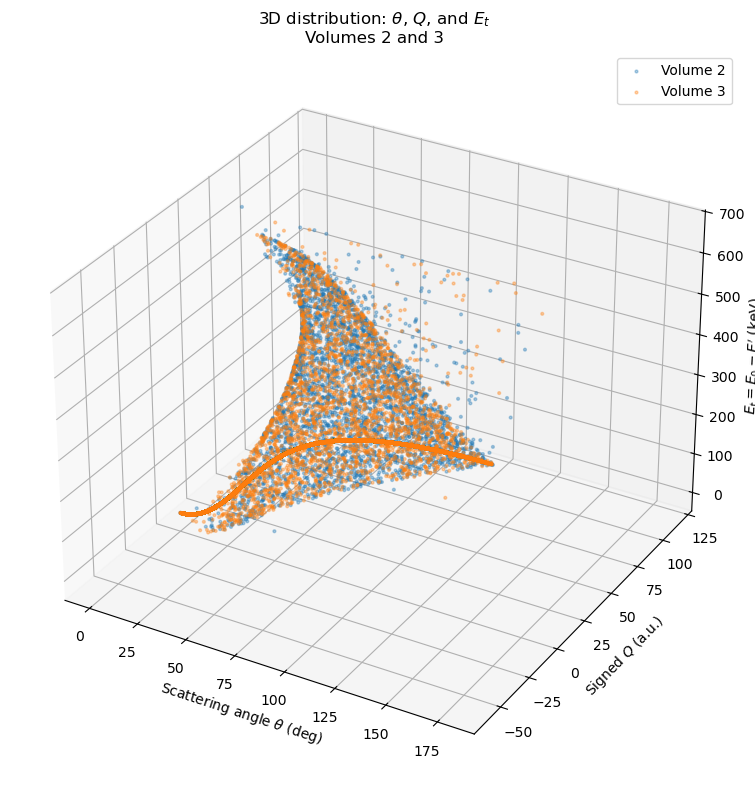

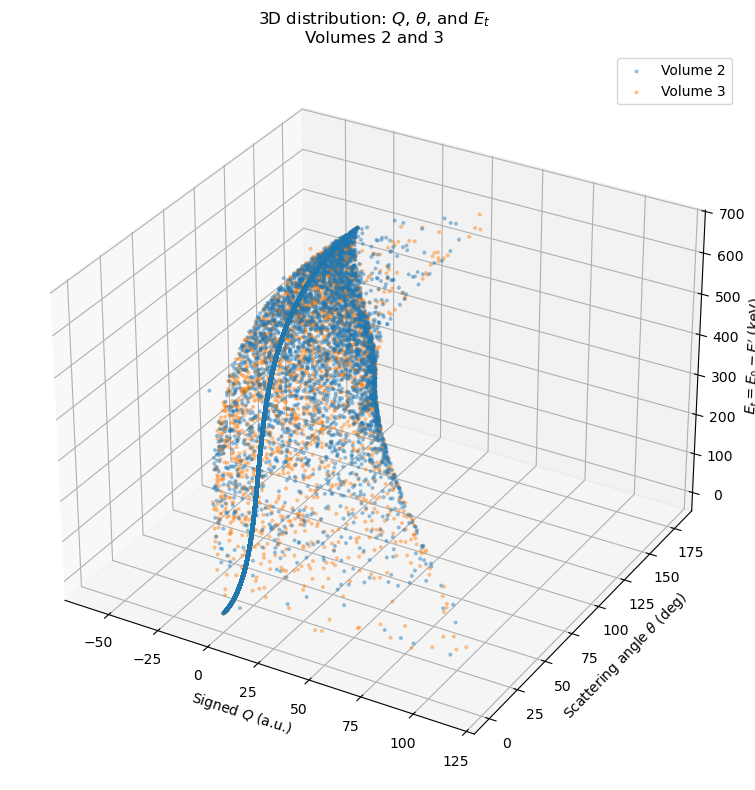


Saved CSV:
volume2_volume3_theta_Q_Et_3D.csv


In [13]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# USER SETTINGS
# =====================================================
file_path = "/root/geant4/detector/Lung_ICRP/lung.root"
tree_name = "t"

E0 = 662.0       # Incident gamma energy, keV
ME = 511.0       # Electron rest energy, keV
P_AU = 3.72738   # 1 a.u. momentum = 3.72738 keV/c

selected_volumes = [2, 3]
compton_process = 2013
gamma_pdg = 22

# Incident beam direction: /gps/direction 0 -1 0
incident_direction = np.array(
    [0.0, -1.0, 0.0],
    dtype=float
)
incident_direction /= np.linalg.norm(incident_direction)

csv_file = "volume2_volume3_theta_Q_Et_3D.csv"

# Reduce plotted points if the dataset is extremely large.
# All valid records are still saved in the CSV.
maximum_plot_points_per_volume = 50000

# =====================================================
# OPEN ROOT FILE
# =====================================================
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"ROOT file does not exist:\n{file_path}"
    )

root_file = ROOT.TFile.Open(file_path)

if not root_file or root_file.IsZombie():
    raise RuntimeError(
        f"Could not open ROOT file:\n{file_path}"
    )

tree = root_file.Get(tree_name)

if tree is None:
    root_file.Close()
    raise RuntimeError(
        f"TTree '{tree_name}' was not found."
    )

print("Total TTree entries:", tree.GetEntries())

# =====================================================
# CHECK REQUIRED ALIGNED BRANCHES
# =====================================================
required_branches = [
    "pdg",
    "pro",
    "vlm",
    "k",
    "px",
    "py",
    "pz"
]

available_branches = {
    branch.GetName()
    for branch in tree.GetListOfBranches()
}

missing_branches = [
    name
    for name in required_branches
    if name not in available_branches
]

if missing_branches:
    root_file.Close()
    raise RuntimeError(
        "Missing branches: " + ", ".join(missing_branches)
    )

# =====================================================
# STORAGE
# =====================================================
rows = []

selected_counts = {
    2: 0,
    3: 0
}

valid_counts = {
    2: 0,
    3: 0
}

# =====================================================
# LOOP OVER TTREE
# =====================================================
for event_number, event in enumerate(tree):

    # Use only aligned tracking branches.
    # Do not include the ROOT et branch.
    n_records = min(
        len(event.pdg),
        len(event.pro),
        len(event.vlm),
        len(event.k),
        len(event.px),
        len(event.py),
        len(event.pz)
    )

    for i in range(n_records):

        pdg = int(event.pdg[i])
        process = int(event.pro[i])
        volume = int(event.vlm[i])

        # Gamma Compton records in volumes 2 and 3
        if volume not in selected_volumes:
            continue

        if pdg != gamma_pdg:
            continue

        if process != compton_process:
            continue

        selected_counts[volume] += 1

        # -------------------------------------------------
        # Scattered gamma energy E' = k
        # -------------------------------------------------
        Eprime = float(event.k[i])

        if (
            not np.isfinite(Eprime)
            or Eprime <= 0.0
            or Eprime > E0
        ):
            continue

        # Energy transfer
        Et = E0 - Eprime

        # -------------------------------------------------
        # Outgoing gamma momentum/direction
        # -------------------------------------------------
        px = float(event.px[i])
        py = float(event.py[i])
        pz = float(event.pz[i])

        outgoing_vector = np.array(
            [px, py, pz],
            dtype=float
        )

        momentum_magnitude = np.linalg.norm(outgoing_vector)

        if (
            not np.isfinite(momentum_magnitude)
            or momentum_magnitude <= 0.0
        ):
            continue

        outgoing_direction = (
            outgoing_vector / momentum_magnitude
        )

        # -------------------------------------------------
        # Actual event scattering angle
        # -------------------------------------------------
        cos_theta = float(
            np.dot(
                incident_direction,
                outgoing_direction
            )
        )

        cos_theta = float(
            np.clip(cos_theta, -1.0, 1.0)
        )

        theta_rad = np.arccos(cos_theta)
        theta_deg = np.degrees(theta_rad)

        # -------------------------------------------------
        # Photon momentum transfer
        # -------------------------------------------------
        q_squared = (
            E0**2
            + Eprime**2
            - 2.0 * E0 * Eprime * cos_theta
        )

        if (
            not np.isfinite(q_squared)
            or q_squared <= 0.0
        ):
            continue

        q_c = np.sqrt(q_squared)

        # -------------------------------------------------
        # Longitudinal electron momentum Q
        # -------------------------------------------------
        Q_keV_c = (
            ME / q_c
        ) * (
            Et
            - q_c**2 / (2.0 * ME)
        )

        Q_au = Q_keV_c / P_AU

        if not np.isfinite(Q_au):
            continue

        rows.append({
            "event_number": event_number,
            "record_index": i,
            "volume": volume,
            "pdg": pdg,
            "pro": process,

            "E0_keV": E0,
            "Eprime_k_keV": Eprime,
            "Et_E0_minus_Eprime_keV": Et,

            "px": px,
            "py": py,
            "pz": pz,

            "cos_theta": cos_theta,
            "theta_deg": theta_deg,

            "q_gamma_keV_c": q_c,
            "Q_keV_c": Q_keV_c,
            "Q_signed_au": Q_au,
            "Q_absolute_au": abs(Q_au)
        })

        valid_counts[volume] += 1

root_file.Close()

# =====================================================
# CREATE AND SAVE CSV
# =====================================================
results = pd.DataFrame(rows)

if results.empty:
    raise RuntimeError(
        "No valid gamma-Compton records were found "
        "for volumes 2 and 3."
    )

results.to_csv(csv_file, index=False)

print("\nRecord summary")
print("----------------")

for volume in selected_volumes:
    print(f"\nVolume {volume}")
    print("Selected records:", selected_counts[volume])
    print("Valid reconstructed records:", valid_counts[volume])

print("\nFirst 10 rows:")
print(results.head(10))

# =====================================================
# SEPARATE VOLUMES
# =====================================================
v2 = results[results["volume"] == 2].copy()
v3 = results[results["volume"] == 3].copy()

# =====================================================
# RANDOM SUBSAMPLING FOR DISPLAY ONLY
# =====================================================
# Plotting millions of markers makes the graph slow and solid-looking.
def sample_for_plot(data, maximum_points, seed=12345):
    if len(data) <= maximum_points:
        return data

    return data.sample(
        n=maximum_points,
        random_state=seed
    )

v2_plot = sample_for_plot(
    v2,
    maximum_plot_points_per_volume,
    seed=12345
)

v3_plot = sample_for_plot(
    v3,
    maximum_plot_points_per_volume,
    seed=54321
)

print("\nPoints displayed in 3D plot:")
print("Volume 2:", len(v2_plot))
print("Volume 3:", len(v3_plot))

# =====================================================
# 3D PLOT:
# x = theta
# y = Q
# z = Et
# =====================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    v2_plot["theta_deg"],
    v2_plot["Q_signed_au"],
    v2_plot["Et_E0_minus_Eprime_keV"],
    s=4,
    alpha=0.35,
    label="Volume 2"
)

ax.scatter(
    v3_plot["theta_deg"],
    v3_plot["Q_signed_au"],
    v3_plot["Et_E0_minus_Eprime_keV"],
    s=4,
    alpha=0.35,
    label="Volume 3"
)

ax.set_xlabel(r"Scattering angle $\theta$ (deg)")
ax.set_ylabel(r"Signed $Q$ (a.u.)")
ax.set_zlabel(r"$E_t=E_0-E'$ (keV)")

ax.set_title(
    r"3D distribution: $\theta$, $Q$, and $E_t$"
    "\nVolumes 2 and 3"
)

ax.legend()
plt.tight_layout()
plt.show()

# =====================================================
# ALTERNATIVE 3D ORIENTATION:
# x = Q
# y = theta
# z = Et
# =====================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    v2_plot["Q_signed_au"],
    v2_plot["theta_deg"],
    v2_plot["Et_E0_minus_Eprime_keV"],
    s=4,
    alpha=0.35,
    label="Volume 2"
)

ax.scatter(
    v3_plot["Q_signed_au"],
    v3_plot["theta_deg"],
    v3_plot["Et_E0_minus_Eprime_keV"],
    s=4,
    alpha=0.35,
    label="Volume 3"
)

ax.set_xlabel(r"Signed $Q$ (a.u.)")
ax.set_ylabel(r"Scattering angle $\theta$ (deg)")
ax.set_zlabel(r"$E_t=E_0-E'$ (keV)")

ax.set_title(
    r"3D distribution: $Q$, $\theta$, and $E_t$"
    "\nVolumes 2 and 3"
)

ax.legend()
plt.tight_layout()
plt.show()

print("\nSaved CSV:")
print(csv_file)

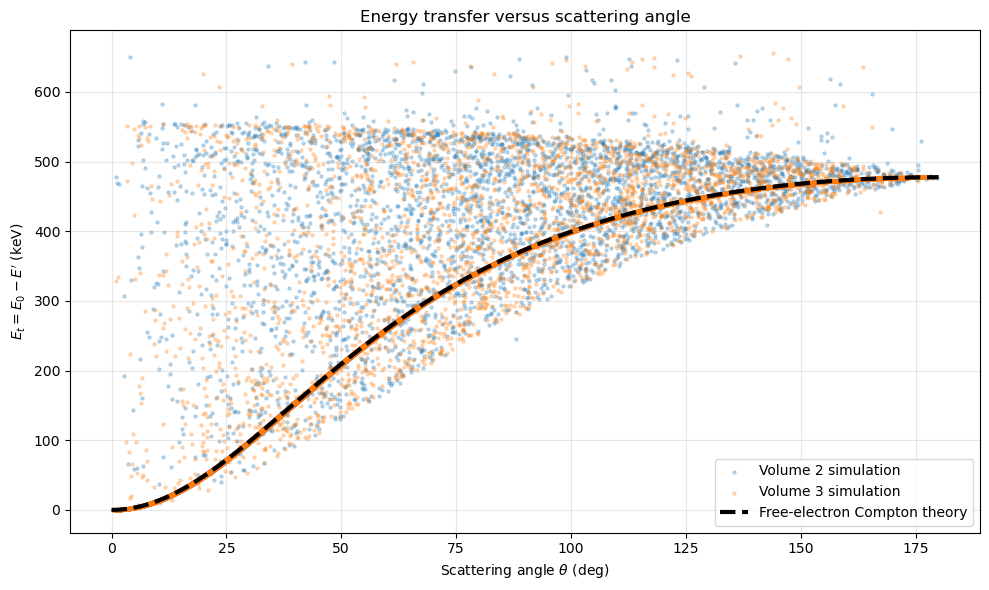

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# CONSTANTS
# =====================================================
E0 = 662.0   # keV
ME = 511.0   # keV

# =====================================================
# FREE-ELECTRON COMPTON THEORY
# =====================================================
theta_theory_deg = np.linspace(0.01, 180.0, 1000)
theta_theory_rad = np.radians(theta_theory_deg)

# Scattered photon energy for a free stationary electron
Eprime_theory = E0 / (
    1.0
    + (E0 / ME)
    * (1.0 - np.cos(theta_theory_rad))
)

# Theoretical energy transfer
Et_theory = E0 - Eprime_theory

# =====================================================
# 2D COMPARISON
# =====================================================
plt.figure(figsize=(10, 6))

plt.scatter(
    v2_plot["theta_deg"],
    v2_plot["Et_E0_minus_Eprime_keV"],
    s=5,
    alpha=0.25,
    label="Volume 2 simulation"
)

plt.scatter(
    v3_plot["theta_deg"],
    v3_plot["Et_E0_minus_Eprime_keV"],
    s=5,
    alpha=0.25,
    label="Volume 3 simulation"
)

# Explicitly make theory visually distinct
plt.plot(
    theta_theory_deg,
    Et_theory,
    linewidth=3.0,
    linestyle="--",
    color="black",
    label="Free-electron Compton theory"
)

plt.xlabel(r"Scattering angle $\theta$ (deg)")
plt.ylabel(r"$E_t=E_0-E'$ (keV)")
plt.title("Energy transfer versus scattering angle")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

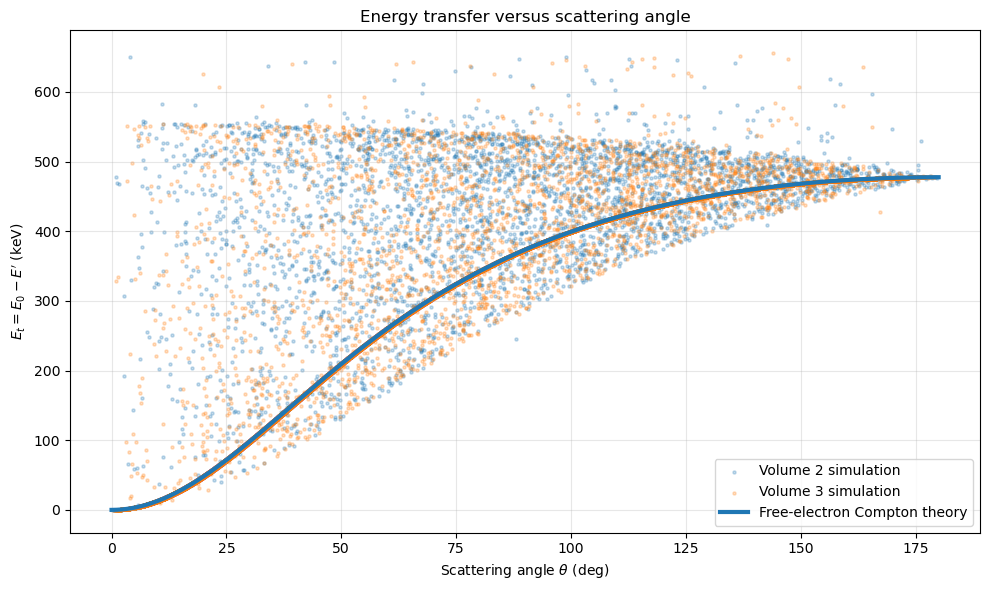

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    v2_plot["theta_deg"],
    v2_plot["Et_E0_minus_Eprime_keV"],
    s=5,
    alpha=0.25,
    label="Volume 2 simulation"
)

plt.scatter(
    v3_plot["theta_deg"],
    v3_plot["Et_E0_minus_Eprime_keV"],
    s=5,
    alpha=0.25,
    label="Volume 3 simulation"
)

plt.plot(
    theta_theory_deg,
    Et_theory,
    linewidth=3.0,
    label="Free-electron Compton theory"
)

plt.xlabel(r"Scattering angle $\theta$ (deg)")
plt.ylabel(r"$E_t=E_0-E'$ (keV)")
plt.title(
    r"Energy transfer versus scattering angle"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()